**First I imported all of the packages I would need to build my ML pipeline:**

In [1]:
import gdown
import pandas as pd

# Model selection and evaluation
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV

# Preprocessing and pipelines
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#Dimensionality reduction for embeddings
from sklearn.decomposition import PCA


**Next, I downloaded the test and training datasets:**

In [2]:
# Download test data
file_id = '1qXFJPcwPGASX581Do6cYsP1A4n5_HdmS'
gdown.download(id=file_id,  quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1qXFJPcwPGASX581Do6cYsP1A4n5_HdmS
To: /content/test.csv
100%|██████████| 12.5M/12.5M [00:00<00:00, 130MB/s]


'test.csv'

In [3]:
# Download training data
file_id ='13CxaCVT-V0M6DZuq38p38U_FE50rxXnN'
gdown.download(id=file_id,  quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=13CxaCVT-V0M6DZuq38p38U_FE50rxXnN
From (redirected): https://drive.google.com/uc?id=13CxaCVT-V0M6DZuq38p38U_FE50rxXnN&confirm=t&uuid=3f4e3447-a081-4635-8fd8-01bf4f1d8bc8
To: /content/train.csv
100%|██████████| 168M/168M [00:01<00:00, 153MB/s]


'train.csv'

**Once these were downloaded, I then loaded the training and test datasets into two separate dataframes, using the "ID" column as the index:**

In [4]:
# Load training and hidden test data to dataframes
train_df=pd.read_csv("train.csv")
test_df=pd.read_csv("test.csv")

# Set the "ID" column as the index (not used as a feature)
train_df.set_index("ID", inplace=True)
test_df.set_index("ID", inplace=True)

**I then followed this up with some basic data exploration, to ensure the data was good quality and to check the class balance to help decide how to build my models:**

In [5]:
# Basic data exploration

# Print dataset shape (rows, columns)
print(train_df.shape)

# Check class balance of target variable (y)
# Important for deciding evaluation metrics
print(train_df["y"].value_counts(normalize=True))

# Check for missing values in the dataset
print(train_df.isnull().sum().sum())

(15411, 517)
y
0    0.831224
1    0.168776
Name: proportion, dtype: float64
0


**Then I built the validation set, and ensured there were no duplicated samples in the training or validation partitions:**

In [6]:
# Build validation set
X_train=train_df.drop(columns=["y"])
y_train=train_df["y"]
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [42]:
# Check for duplicated samples in training and validation partitions
print(X_train_split.duplicated().sum())
print(X_val.duplicated().sum())

0
0


In [8]:
# Visualise X_train
"""
X_train input features:

Disease: Binary input indicating if, 1 = Disease predominantly driven by germline mutations or 0 = Disease predominantly driven by somatic mutations

rep: Integer (1–5) indicating the repeat index from a data augmentation strategy (to increase training dataset size).

emb_0 to emb_511: 512-dimensional feature vector, Deep learning–derived embedding of publicly available multi-omics data for each gene set

sc: Literature-based co-mention score derived from in-house computational analysis of PubMed (January 2025).
Providing a normalised measure of how frequently genes in a set are mentioned together in the context of the same disease.
Higher values indicate a greater likelihood that the genes are associated with the same disease

num_genes: Number of genes in the gene set being evaluated, divided by 1000

y_train target features you are aiming to predict with your ML method:

y: Binary target feature, 1==Genes are involved in the same disease, 0==Genes are not involved in the same disease
"""

X_train_split.head()

,disease,rep,num_genes,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_503,emb_504,emb_505,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511,sc
ID,,,,,,,,,,,,,,,,,,,,,
11210,1,3,0.056,-0.004681,-0.004141,0.007356,-0.005355,-0.005115,-0.001478,-0.000229,...,-0.001887,0.013654,0.002669,0.007646,0.016279,-0.005502,0.002754,-0.005163,-0.003222,0.652422
1347,0,3,0.007,-0.021622,0.001784,0.001317,-0.015505,-0.013637,-0.002508,0.003189,...,-0.006325,-0.006477,0.000357,-0.001149,0.006732,-0.004618,-0.006361,-0.004835,-0.018669,-0.646324
10363,1,1,0.005,-0.004248,0.002859,0.017020,-0.005545,-0.022961,-0.001918,-0.026543,...,-0.003233,0.029640,-0.006883,0.043085,-0.007413,-0.019051,0.002225,0.000806,0.009232,-0.563179
316,1,1,0.004,0.008963,-0.036438,-0.004386,-0.020336,-0.021566,0.009186,0.015676,...,0.000571,0.025706,-0.014074,-0.005179,0.017328,0.014250,-0.016409,0.029984,-0.036964,1.129767
10638,1,3,0.004,-0.012474,0.008436,0.017385,0.001176,0.006037,-0.000601,0.000903,...,0.001008,-0.042057,-0.009665,-0.027703,0.069378,0.018560,-0.004430,-0.001781,-0.011582,0.365654


**I then began building models, starting with a basic logistic regression model, and checked the training vs validation performance of the model to check for over- or under-fitting or leakage:**

In [30]:
# Start by creating a baseline imbalance-aware logistic regression model
log_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_clf.fit(X_train_split, y_train_split)

val_preds = log_clf.predict(X_val)

print("LogReg F1:", f1_score(y_val, val_preds))

LogReg F1: 0.8338815789473685


In [31]:
# Check training vs validation performance
train_preds = log_clf.predict(X_train)

print("Train F1:", f1_score(y_train, train_preds))
print("Val F1:", f1_score(y_val, val_preds))

Train F1: 0.8504252126063031
Val F1: 0.8338815789473685


**I followed this by creating a stronger model using a Random Forest Classifier, again checking training vs validation performance:**

In [28]:
# Try another, stronger model for this task (Random Forest Classifier)
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_clf.fit(X_train_split, y_train_split)

val_preds = rf_clf.predict(X_val)

print("RF F1:", f1_score(y_val, val_preds))

RF F1: 0.7585394581861012


In [29]:
# Check training vs validation performance
train_preds = rf_clf.predict(X_train)

print("Train F1:", f1_score(y_train, train_preds))
print("Val F1:", f1_score(y_val, val_preds))

Train F1: 0.813953488372093
Val F1: 0.7585394581861012


**Next, I performed some hyperparameter tuning using GridSearchCV and applied the best parameters to a new tuned Random Forest classifier, again checking training vs validation performance:**

In [22]:
# Hyperparameter tuning
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train_split, y_train_split)

print("Best parameters:", grid.best_params_)
print("Best F1 score:", grid.best_score_)

tuned_rf_clf = grid.best_estimator_

tuned_rf_clf.fit(X_train_split, y_train_split)

val_preds = tuned_rf_clf.predict(X_val)

print("Tuned RF F1:", f1_score(y_val, val_preds))

Best parameters: {'max_depth': None, 'n_estimators': 100}
Best F1 score: 0.9326035121504113
Tuned RF F1: 0.9410589410589411


In [23]:
# Check training vs validation performance
train_preds = tuned_rf_clf.predict(X_train)

print("Train F1:", f1_score(y_train, train_preds))
print("Val F1:", f1_score(y_val, val_preds))

Train F1: 0.9885414643620121
Val F1: 0.9410589410589411


**I then created one more model, performing embedding optimisation using PCA, and checked training vs validation performance for this model:**

In [24]:
# Perform embeddings optimisation (PCA)
pca_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=100)),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

pca_clf.fit(X_train_split, y_train_split)

val_preds = pca_clf.predict(X_val)

print("PCA RF F1:", f1_score(y_val, val_preds))

PCA RF F1: 0.7370892018779343


In [26]:
# Check training vs validation performance
train_preds = pca_clf.predict(X_train)

print("Train F1:", f1_score(y_train, train_preds))
print("Val F1:", f1_score(y_val, val_preds))

Train F1: 0.9552
Val F1: 0.7370892018779343


**The relatively low F1 score in comparison with the other models tells me that the embeddings are already highly informative and that reducing them appears to hurt overall performance.**

**The tuned RF classifier turned out to be the strongest model, with a F1 score of 0.94 for the validation set. However there still appeared to be some overfitting, with the F1 score for the training set being 0.98. I modified this model slightly to stabilise it before training it on the full training set:**

In [33]:
# tuned_rf model still slightly overfitting
# modify the initial model to stabilise before training on full dataset
tuned_rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42
)

tuned_rf_clf.fit(X_train_split, y_train_split)

val_preds = tuned_rf_clf.predict(X_val)

print("Tuned RF F1:", f1_score(y_val, val_preds))


Tuned RF F1: 0.9135802469135802


In [34]:
# Check training vs validation performance
train_preds = tuned_rf_clf.predict(X_train)

print("Train F1:", f1_score(y_train, train_preds))
print("Val F1:", f1_score(y_val, val_preds))

Train F1: 0.9469850263051396
Val F1: 0.9135802469135802


**This made the difference between training and validation F1 scores smaller, so the model is now less likely to be overfitting.**

**I then plotted a Confusion Matrix to show how well the model classifies positive and negative samples:**

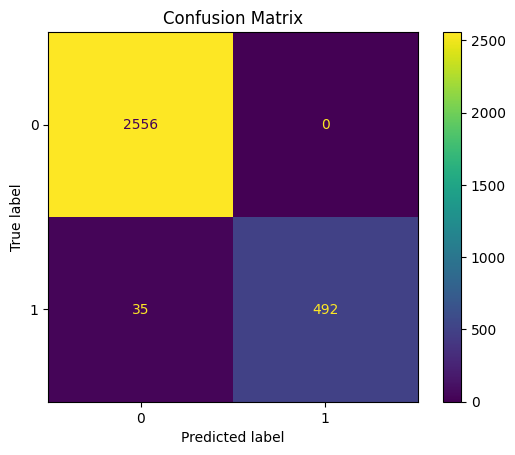

In [43]:
# Plot a confusion matrix for the tuned model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on validation set
val_preds = tuned_rf_clf.predict(X_val)

# Compute confusion matrix
cm = confusion_matrix(y_val, val_preds)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

**As you can see from the Confusion Matrix, most of the samples are labelled correctly, with 0 false positives and only 35 false negatives.**

**Finally, I trained the tuned model on the full training dataset:**

In [35]:
# Train final model on full dataset
final_model = tuned_rf_clf
final_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_leaf=2, random_state=42)

**With the model now confirmed to be strong, I used it to make predictions on the hidden test set:**

In [36]:
# Make predictions on hidden test set
test_preds = final_model.predict(test_df)

**I then wrote outputs for the predictions to upload to Turnitin, and ensured the format of the output file was correct:**

In [50]:
# Write outputs for uploading to turnitin
test_df = test_df.reset_index()
df_res_test=test_df[["ID"]].copy()
df_res_test["PREDICTION"] = list(test_preds)
df_res_test.to_csv("ml_results.csv", index=False)

# Download results file
from google.colab import files
files.download('ml_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
# Check there are 2 columns and that the ID starts at 15411
!head -n3  ml_results.csv

ID,PREDICTION
15411,0
15412,0


In [49]:
# Check there are 1155 predictions (full test set)
!wc -l ml_results.csv

1155 ml_results.csv
